In [1]:
from collections import defaultdict
from sklearn.model_selection import train_test_split
from torch import nn
from torchvision import transforms
from torchvision.models import mobilenet_v2

import os
import torch
import torchvision
import kagglehub
import matplotlib.pyplot as plt

In [2]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print('device:', device)

device: mps


In [3]:
path = kagglehub.dataset_download('alexattia/the-simpsons-characters-dataset')

path

'/Users/andreivasilev/.cache/kagglehub/datasets/alexattia/the-simpsons-characters-dataset/versions/4'

In [4]:
data_dir = os.path.join(path, 'simpsons_dataset')

data_dir

'/Users/andreivasilev/.cache/kagglehub/datasets/alexattia/the-simpsons-characters-dataset/versions/4/simpsons_dataset'

In [5]:
input_size = 224

train_transform_good = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
])

train_transform_bad = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomResizedCrop(input_size, scale=(0.1, 0.3)),
    transforms.ColorJitter(2.0, 2.0, 2.0),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
])

In [6]:
full_dataset = torchvision.datasets.ImageFolder(data_dir)

indices = list(range(len(full_dataset)))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=full_dataset.targets,
    random_state=42
)

In [7]:
# dataloaders
def get_dataloaders(train_transform):
    train_dataset_full = torchvision.datasets.ImageFolder(
        data_dir,
        transform=train_transform
    )

    val_dataset_full = torchvision.datasets.ImageFolder(
        data_dir,
        transform=val_transform
    )

    train_dataset = torch.utils.data.Subset(train_dataset_full, train_idx)
    val_dataset = torch.utils.data.Subset(val_dataset_full, val_idx)

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=64, shuffle=True
    )

    val_loader = torch.utils.data.DataLoader(
        val_dataset, batch_size=64, shuffle=False
    )

    return train_loader, val_loader, len(train_dataset_full.classes)

In [8]:
def get_model(num_classes, fine_tune=False):
    model = mobilenet_v2(weights='IMAGENET1K_V1')

    model.classifier[1] = nn.Linear(model.last_channel, num_classes)

    # freeze
    for param in model.features.parameters():
        param.requires_grad = False

    # fine-tune
    if fine_tune:
        for param in model.features[-3:].parameters():
            param.requires_grad = True

    return model.to(device)

In [9]:
def train(model, train_loader, val_loader, optimizer, scheduler, epochs=10):
    history = defaultdict(list)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        train_loss, train_acc = 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            logits = model(X)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_acc += (logits.argmax(1) == y).float().mean().item()

        train_loss /= len(train_loader)
        train_acc /= len(train_loader)

        model.eval()
        val_loss, val_acc = 0, 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)

                logits = model(X)
                loss = criterion(logits, y)

                val_loss += loss.item()
                val_acc += (logits.argmax(1) == y).float().mean().item()

        val_loss /= len(val_loader)
        val_acc /= len(val_loader)

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()

        print(f'Epoch {epoch + 1}: '
              f'train_acc={train_acc:.4f}, val_acc={val_acc:.4f}')

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    return history

In [10]:
results = {}

In [11]:
# 1
train_loader, val_loader, num_classes = get_dataloaders(train_transform_good)

model = get_model(num_classes, fine_tune=False)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.1
)

results['good_stepLR'] = train(
    model, train_loader, val_loader, optimizer, scheduler
)

Epoch 1: train_acc=0.4888, val_acc=0.4917
Epoch 2: train_acc=0.4918, val_acc=0.4863
Epoch 3: train_acc=0.4901, val_acc=0.4736
Epoch 4: train_acc=0.5000, val_acc=0.4760
Epoch 5: train_acc=0.5020, val_acc=0.4761
Epoch 6: train_acc=0.5009, val_acc=0.4730
Epoch 7: train_acc=0.5016, val_acc=0.4731
Epoch 8: train_acc=0.5056, val_acc=0.4734
Epoch 9: train_acc=0.5060, val_acc=0.4726
Epoch 10: train_acc=0.5029, val_acc=0.4734


In [12]:
# 2
model = get_model(num_classes, fine_tune=False)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.1
)

results['good_plateau'] = train(
    model, train_loader, val_loader, optimizer, scheduler
)

Epoch 1: train_acc=0.4906, val_acc=0.4849
Epoch 2: train_acc=0.4916, val_acc=0.4815
Epoch 3: train_acc=0.4843, val_acc=0.4782
Epoch 4: train_acc=0.4896, val_acc=0.4743
Epoch 5: train_acc=0.4872, val_acc=0.4683
Epoch 6: train_acc=0.4904, val_acc=0.4710
Epoch 7: train_acc=0.4908, val_acc=0.4607
Epoch 8: train_acc=0.5039, val_acc=0.4626
Epoch 9: train_acc=0.5044, val_acc=0.4592
Epoch 10: train_acc=0.5042, val_acc=0.4598


In [13]:
# 3
train_loader, val_loader, num_classes = get_dataloaders(train_transform_bad)

model = get_model(num_classes, fine_tune=False)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.1
)

results['bad_aug'] = train(
    model, train_loader, val_loader, optimizer, scheduler
)

Epoch 1: train_acc=0.4978, val_acc=0.5002
Epoch 2: train_acc=0.4956, val_acc=0.4998
Epoch 3: train_acc=0.4937, val_acc=0.4984
Epoch 4: train_acc=0.4975, val_acc=0.4987
Epoch 5: train_acc=0.4975, val_acc=0.4990
Epoch 6: train_acc=0.4978, val_acc=0.4991
Epoch 7: train_acc=0.4975, val_acc=0.4994
Epoch 8: train_acc=0.4987, val_acc=0.4987
Epoch 9: train_acc=0.4986, val_acc=0.4991
Epoch 10: train_acc=0.4993, val_acc=0.4994


In [14]:
# 4
train_loader, val_loader, num_classes = get_dataloaders(train_transform_good)

model = get_model(num_classes, fine_tune=True)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.1
)

results['fine_tune'] = train(
    model, train_loader, val_loader, optimizer, scheduler
)

Epoch 1: train_acc=0.4825, val_acc=0.4891
Epoch 2: train_acc=0.4865, val_acc=0.4638
Epoch 3: train_acc=0.4952, val_acc=0.4481
Epoch 4: train_acc=0.5137, val_acc=0.4414
Epoch 5: train_acc=0.5205, val_acc=0.4348
Epoch 6: train_acc=0.5150, val_acc=0.4322
Epoch 7: train_acc=0.5239, val_acc=0.4325
Epoch 8: train_acc=0.5278, val_acc=0.4298
Epoch 9: train_acc=0.5218, val_acc=0.4301
Epoch 10: train_acc=0.5228, val_acc=0.4317


In [15]:
for name, hist in results.items():
    print(name, 'max val acc:', max(hist['val_acc']))

good_stepLR max val acc: 0.4916719543147208
good_plateau max val acc: 0.4849302030456853
bad_aug max val acc: 0.5001586294416244
fine_tune max val acc: 0.48913388324873097


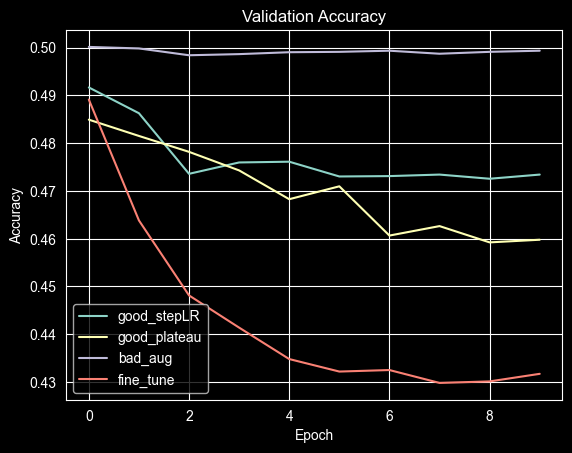

In [16]:
plt.figure()

for name, hist in results.items():
    plt.plot(hist['val_acc'], label=name)

plt.legend()
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()